<a href="https://colab.research.google.com/github/yalindi/2425568_ml/blob/main/2425568.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/yalindi/2425568_ml.git

Cloning into '2425568_ml'...
remote: Enumerating objects: 42, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 42 (delta 16), reused 20 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (42/42), 998.69 KiB | 4.03 MiB/s, done.
Resolving deltas: 100% (16/16), done.


##**Import libraries**


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.tree import DecisionTreeClassifier

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn


%matplotlib inline

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import precision_score,recall_score,f1_score
from sklearn.metrics import RocCurveDisplay

# **Data** **exploration** **and** **Preprocessing** **Data**

In [3]:
df = pd.read_csv('/content/2425568_ml/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [4]:
df.shape

(7043, 21)

In [5]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
#checking missing values
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


Text(0, 0.5, 'count')

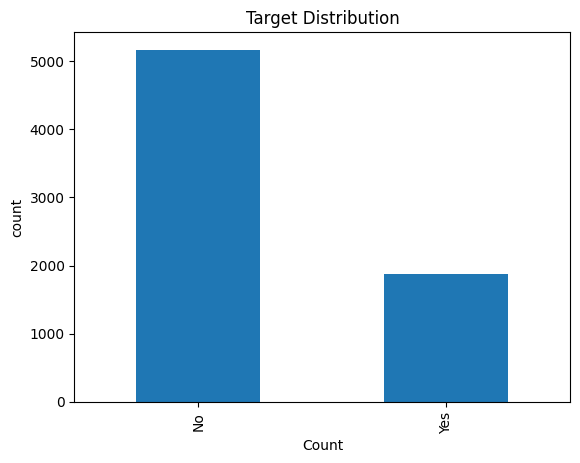

In [9]:
#Traget Distribution
df['Churn'].value_counts().plot(kind='bar')
plt.title("Target Distribution")
plt.xlabel("Count")
plt.ylabel("count")

In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [13]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [14]:
#Impute missing TotalCharges
df_copy=df
df_copy['TotalCharges']=df['TotalCharges'].fillna(df['MonthlyCharges']*df['tenure'])

In [ ]:
df_copy.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df_copy=df.drop("customerID",axis=1)

In [ ]:
df_copy.head().T

,0,1,2,3,4
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No
OnlineBackup,Yes,No,Yes,No,No


In [ ]:
#Covert Yes/No columns to 1/0
for col in df_copy.columns:
  if set(df_copy[col].unique())==set(['Yes','No']):
    df_copy[col]=df_copy[col].map({'Yes':1,'No':0})

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   object 


In [ ]:
#Convert Gender Column Male=1 Female=0
if 'gender' in df_copy.columns:
  df_copy['gender']=df_copy['gender'].map({'Male':1,'Female':0})

df_copy['gender'].dtypes

dtype('int64')

In [ ]:
X=df_copy.drop('Churn',axis=1)
y=df_copy['Churn']

In [ ]:
for col in df_copy.columns:
  if (df_copy[col].dtypes)=='object':
    print(col)

MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaymentMethod


In [ ]:
#Split the data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [ ]:
#Scale the numerical data
numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]
Scaler = StandardScaler()

X_train[numerical_features] = Scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = Scaler.transform(X_test[numerical_features])


In [ ]:
#One-hot encoder
categorical_features=['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod']
one_hot=OneHotEncoder()
transformer=ColumnTransformer([("one_hot",
                               one_hot,
                               categorical_features)],
                              remainder="passthrough")
X_train=transformer.fit_transform(X_train)
X_test=transformer.transform(X_test)

# **DecisionTreeClassifier**

In [ ]:
#fit the model
model_1=DecisionTreeClassifier(random_state=42,class_weight="balanced")
model_1.fit(X_train,y_train)


DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [ ]:
model_1.score(X_test,y_test)

0.7382867960246096

### Hyperparameter Tuning with RandomizedSearchCV


In [ ]:
rs_grid={
    "criterion":["gini", "entropy", "log_loss"],
    "max_depth":np.arange(1,10),
    "min_samples_split":np.arange(2,10),
    "min_samples_leaf":[1,2,4,5,7,8,10]

}
np.random.seed(42)

rs=RandomizedSearchCV(model_1,
                      param_distributions=rs_grid,
                      cv=5,
                      n_iter=30,
                      verbose=True)

rs.fit(X_train,y_train)
rs.best_params_

Fitting 5 folds for each of 30 candidates, totalling 150 fits


{'min_samples_split': np.int64(7),
 'min_samples_leaf': 4,
 'max_depth': np.int64(5),
 'criterion': 'log_loss'}

In [ ]:
rs.score(X_test,y_test)

0.7586370089919545

### Hyperparameter Tuning with gridSearchCV

In [ ]:
gs_grid={
    "criterion":["entropy", "log_loss"],
    "max_depth":[5],
    "min_samples_split":[5,6,7,9],
    "min_samples_leaf":[3,4,6,8]
}

np.random.seed(42)

gs=GridSearchCV(model_1,
                param_grid=gs_grid,
                cv=5,
                verbose=True)

gs.fit(X_train,y_train)
gs.best_params_

Fitting 5 folds for each of 32 candidates, totalling 160 fits


{'criterion': 'entropy',
 'max_depth': 5,
 'min_samples_leaf': 4,
 'min_samples_split': 5}

In [ ]:
gs.score(X_test,y_test)

0.7586370089919545

In [ ]:
#save
import pickle
pickle.dump(gs,open("best_churn_decision_tree_model.pkl","wb"))

### evaluate model_1

In [ ]:
y_preds=gs.predict(X_test)

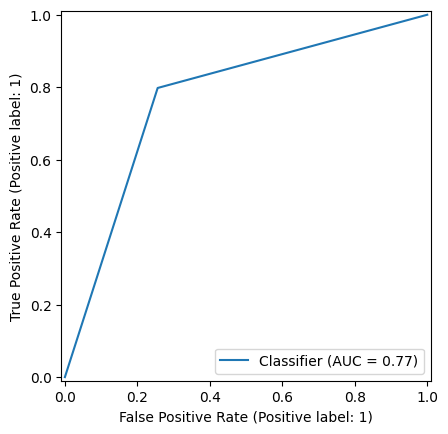

In [ ]:
RocCurveDisplay.from_predictions(y_test,y_preds)

In [ ]:
confusion_matrix(y_test, y_preds)

array([[1145,  394],
       [ 116,  458]])

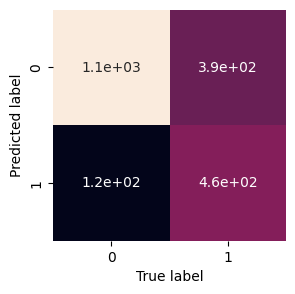

In [ ]:
def plot_conf_mat(y_test, y_preds):
    """
    Plots a nice looking confusion matrix using Seaborn's heatmap()
    """
    fig, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True,
                     cbar=False)
    plt.xlabel("True label")
    plt.ylabel("Predicted label")

    bottom, top = ax.get_ylim()
    #ax.set_ylim(bottom + 0.5, top - 0.5)
    plt.show()

plot_conf_mat(y_test, y_preds)

In [ ]:
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1539
           1       0.54      0.80      0.64       574

    accuracy                           0.76      2113
   macro avg       0.72      0.77      0.73      2113
weighted avg       0.81      0.76      0.77      2113



In [ ]:
# cross-validated accuracy
X_encoded = transformer.transform(X)
cv_acc = cross_val_score(gs,
                         X_encoded,
                         y,
                         cv=5,
                         scoring="accuracy")
cv_acc=np.mean(cv_acc)

# cross-validated precision
cv_precision = cross_val_score(gs,
                         X_encoded,
                         y,
                         cv=5,
                         scoring="precision")
cv_precision=np.mean(cv_precision)

# cross-validated recall
cv_recall = cross_val_score(gs,
                         X_encoded,
                         y,
                         cv=5,
                         scoring="recall")
cv_recall = np.mean(cv_recall)

# cross-validated f1
cv_f1 = cross_val_score(gs,
                         X_encoded,
                         y,
                         cv=5,
                         scoring="f1")
cv_f1 = np.mean(cv_f1)

print("cross-validated accuracy :",cv_acc)
print("cross-validated precision: ",cv_precision)
print("cross-validated recall: ",cv_recall)
print("cross-validated f1: ",cv_f1)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 

#**Neural Network**

In [ ]:
import tensorflow as tf
random_set_seed=42
tf.random.set_seed(random_set_seed)
np.random.seed(random_set_seed)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {0: class_weights[0], 1: class_weights[1]}

In [ ]:
# Build the model
def build_model(input_shape):
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model


input_shape = (X_train.shape[1],)
model_2 = build_model(input_shape)

In [ ]:
#compile the model
model_2.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics = ['accuracy'])

In [ ]:
#early stopping
early_stopping_main=tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)

#model Summary
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#train the model
history=model_2.fit(
    X_train,y_train,
    epochs=200,
    batch_size=32,
    class_weight=class_weights,
    validation_split=0.2,
    callbacks=[early_stopping_main],
    verbose=1
)

Epoch 1/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.6766 - loss: 0.6451 - val_accuracy: 0.7039 - val_loss: 0.5324
Epoch 2/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7021 - loss: 0.5568 - val_accuracy: 0.7262 - val_loss: 0.4963
Epoch 3/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7171 - loss: 0.5400 - val_accuracy: 0.7140 - val_loss: 0.5148
Epoch 4/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7109 - loss: 0.5245 - val_accuracy: 0.7120 - val_loss: 0.5088
Epoch 5/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7376 - loss: 0.5192 - val_accuracy: 0.7160 - val_loss: 0.5022
Epoch 6/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7433 - loss: 0.5061 - val_accuracy: 0.7231 - val_loss: 0.5050
Epoch 7/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7375 - loss: 0.5115 - val_accuracy: 0.7201 - val_loss: 0.5091
Epoch 8/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7251 - loss: 0.5072 - val_acc

In [ ]:
#Evaluate the model
loss,accuracy=model_2.evaluate(X_test,y_test)
print("Test Loss: ",loss)
print("Test Accuracy: ",accuracy)

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7621 - loss: 0.4785
Test Loss:  0.48801371455192566
Test Accuracy:  0.7534311413764954


In [ ]:
pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 10.9 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt

#Tuning NN
def build_hyper_model(hp):
  model=tf.keras.Sequential()

  hp_layers=hp.Int('num_layers',min_value=1,max_value=3,step=1)
  for i in range(hp_layers):
    units=hp.Int(f'layer_{i}',min_value=16,max_value=256,step=16)
    activation=hp.Choice(f'activation_{i}',values=['relu','tanh'])
    model.add(tf.keras.layers.Dense(units,activation=activation))

    dropout_rate=hp.Float(f'dropout_{i}',min_value=0.0,max_value=0.6,step=0.1)
    model.add(tf.keras.layers.Dropout(dropout_rate))


  model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

  hp_learning_rate=hp.Choice('learning_rate',values=[1e-2,1e-3,1e-4])

  model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
                loss='binary_crossentropy',
                metrics = ['accuracy'])

  return model

In [ ]:
tuner=kt.Hyperband(build_hyper_model,
                   objective='val_accuracy',
                   max_epochs=30,
                   factor=3,
                   directory='tuner_output',
                   project_name='nn_tuning_telco')

In [ ]:
early_stopping=tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)


In [ ]:
tuner.search(X_train,y_train,validation_split=0.2,callbacks=[early_stopping],class_weight=class_weights)

Trial 90 Complete [00h 00m 13s]
val_accuracy: 0.7352941036224365

Best val_accuracy So Far: 0.7586206793785095
Total elapsed time: 00h 11m 53s


In [ ]:
best_hps=tuner.get_best_hyperparameters()[0]
best_hps.values

{'num_layers': 2,
 'layer_0': 32,
 'activation_0': 'relu',
 'dropout_0': 0.4,
 'learning_rate': 0.01,
 'layer_1': 80,
 'activation_1': 'relu',
 'dropout_1': 0.5,
 'layer_2': 48,
 'activation_2': 'relu',
 'dropout_2': 0.30000000000000004,
 'tuner/epochs': 10,
 'tuner/initial_epoch': 0,
 'tuner/bracket': 1,
 'tuner/round': 0}

In [ ]:
model_2=tuner.hypermodel.build(best_hps)
history=model_2.fit(
    X_train,y_train,
    epochs=200,
    batch_size=32,
    class_weight=class_weights,
    validation_split=0.2,
    callbacks=[early_stopping_main],
    verbose=1
)

Epoch 1/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6854 - loss: 0.5902 - val_accuracy: 0.7170 - val_loss: 0.5281
Epoch 2/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7408 - loss: 0.5133 - val_accuracy: 0.7292 - val_loss: 0.5164
Epoch 3/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7321 - loss: 0.5181 - val_accuracy: 0.7140 - val_loss: 0.5173
Epoch 4/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7197 - loss: 0.5077 - val_accuracy: 0.7465 - val_loss: 0.4965
Epoch 5/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7534 - loss: 0.5072 - val_accuracy: 0.7465 - val_loss: 0.5060
Epoch 6/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7406 - loss: 0.5104 - val_accuracy: 0.7394 - val_loss: 0.4947
Epoch 7/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7462 - loss: 0.5077 - val_accuracy: 0.7637 - val_loss: 0.4963
Epoch 8/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7637 - loss: 0.4932 - val_acc

In [ ]:
#Evaluate the model
loss,accuracy=model_2.evaluate(X_test,y_test)
print("Test Loss: ",loss)
print("Test Accuracy: ",accuracy)

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7470 - loss: 0.4644
Test Loss:  0.4702830910682678
Test Accuracy:  0.7430194020271301


In [ ]:
model_2.save("best_churn_NN_model.keras")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("best_churn_NN_model.keras")
